## Экстрактим фичи из картинок при помощи [SIFT](https://docs.opencv.org/4.x/da/df5/tutorial_py_sift_intro.html)

In [61]:
import sys
sys.path.append('../..')

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [62]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report
from tqdm import tqdm
import numpy as np
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

In [63]:
train = pd.read_csv('../../data/01_raw/train_images.csv')
test = pd.read_csv('../../data/01_raw/test_images.csv')

In [64]:
path_to_dataset = Path("../../data/01_raw/sneakers-dataset")

In [65]:
import cv2 as cv

img_path = 'reebok_classic_leather/0004.jpg'
img = cv.imread(path_to_dataset / img_path, cv.IMREAD_GRAYSCALE)
img

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], shape=(140, 105), dtype=uint8)

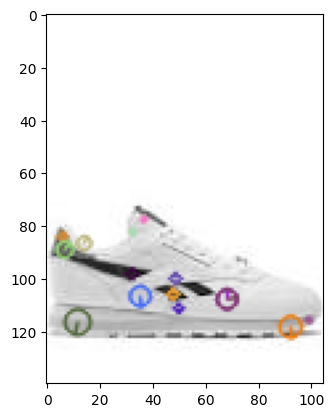

In [66]:
# Для каждого изображения в датафрейме считаем SIFT
sift = cv.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(img, None)
img_with_keypoints = cv.drawKeypoints(img, keypoints, None, flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(img_with_keypoints)

In [67]:
descriptors

array([[  0.,   1., 141., ...,   0.,   2.,   4.],
       [  0.,   0.,   0., ...,   0.,   0.,   1.],
       [  0.,   0.,   0., ...,   0.,   0.,   0.],
       ...,
       [  6.,  87., 102., ...,  25., 123.,   6.],
       [  0.,   0.,   0., ...,   0.,   0.,   5.],
       [  0.,   1.,  11., ...,   0.,   0., 132.]],
      shape=(17, 128), dtype=float32)

In [68]:
feature_df = []
for img_path in train['path']:
    img = cv.imread(path_to_dataset / img_path, cv.IMREAD_GRAYSCALE)
    sift = cv.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(img, None)
    descriptors = pd.DataFrame(descriptors)
    descriptors['path'] = img_path
    feature_df.append(descriptors)
feature_df = pd.concat(feature_df)
feature_df

,0,1,2,3,4,5,6,7,8,9,...,119,120,121,122,123,124,125,126,127,path
0,0.0,0.0,0.0,0.0,79.0,144.0,1.0,0.0,102.0,22.0,...,13.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,6.0,nike_air_force_1_high/0036.jpg
1,0.0,1.0,25.0,14.0,1.0,0.0,0.0,0.0,0.0,11.0,...,36.0,31.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,nike_air_force_1_high/0036.jpg
2,36.0,4.0,0.0,0.0,0.0,0.0,0.0,2.0,137.0,2.0,...,17.0,9.0,36.0,3.0,7.0,74.0,26.0,0.0,0.0,nike_air_force_1_high/0036.jpg
3,19.0,0.0,0.0,0.0,0.0,0.0,0.0,54.0,60.0,0.0,...,1.0,75.0,18.0,0.0,0.0,0.0,0.0,0.0,2.0,nike_air_force_1_high/0036.jpg
4,13.0,2.0,2.0,7.0,1.0,0.0,2.0,26.0,172.0,4.0,...,9.0,5.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,nike_air_force_1_high/0036.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37,4.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,150.0,53.0,...,88.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,nike_air_force_1_low/0137.jpg
38,35.0,92.0,0.0,0.0,0.0,0.0,0.0,2.0,87.0,156.0,...,156.0,16.0,1.0,0.0,0.0,0.0,0.0,1.0,11.0,nike_air_force_1_low/0137.jpg
39,0.0,0.0,2.0,19.0,15.0,57.0,30.0,0.0,138.0,16.0,...,7.0,78.0,36.0,0.0,0.0,0.0,0.0,0.0,3.0,nike_air_force_1_low/0137.jpg
40,5.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,113.0,1.0,...,65.0,59.0,1.0,0.0,0.0,0.0,0.0,0.0,7.0,nike_air_force_1_low/0137.jpg


In [69]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

feature_df[list(range(128))] = scaler.fit_transform(feature_df[list(range(128))])
n_feats = 200
clustering = KMeans(n_feats)
clustering.fit(feature_df[list(range(128))])
feature_df['cluster_feat'] = clustering.predict(feature_df[list(range(128))]).astype(str)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.007s...
[t-SNE] Computed neighbors for 10000 samples in 0.301s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 3.063638
[t-SNE] KL divergence after 250 iterations with early exaggeration: 94.307098
[t-SNE] KL divergence after 1000 iterations: 2.642727


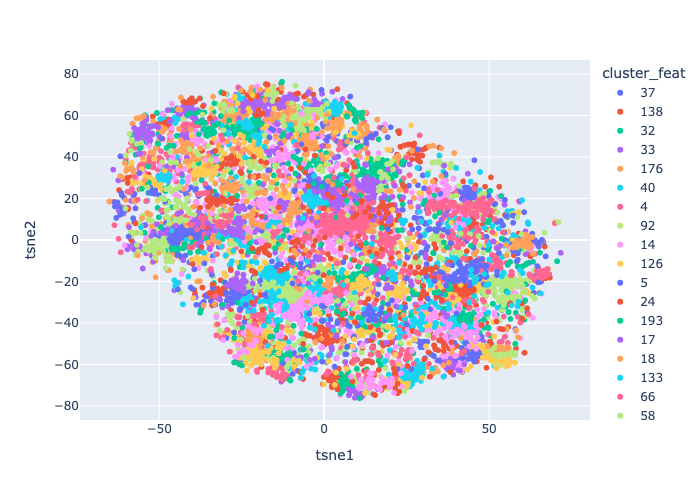

In [70]:
from sklearn.manifold import TSNE
import plotly.express as px
from IPython.display import Image, display


# Assume X is your high-dimensional data matrix and y are labels or target classes
tsne = TSNE(n_components=2, random_state=123, verbose=1)
sample_df = feature_df.sample(10000, random_state=0)
sample_df[['tsne1', 'tsne2']] = tsne.fit_transform(sample_df[list(range(128))])
fig = px.scatter(sample_df, x='tsne1', y='tsne2', color='cluster_feat')
display(Image(fig.to_image('png')))

In [71]:
train.set_index('path', inplace=True)


In [72]:
test.set_index('path', inplace=True)

In [73]:
test_feature_df = []
for img_path in test.index:
    img = cv.imread(path_to_dataset / img_path, cv.IMREAD_GRAYSCALE)
    sift = cv.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(img, None)
    descriptors = pd.DataFrame(descriptors)
    descriptors['path'] = img_path
    test_feature_df.append(descriptors)
test_feature_df = pd.concat(test_feature_df)
test_feature_df

,0,1,2,3,4,5,6,7,8,9,...,119,120,121,122,123,124,125,126,127,path
0,33.0,19.0,7.0,3.0,19.0,16.0,27.0,22.0,4.0,3.0,...,37.0,0.0,1.0,0.0,0.0,30.0,9.0,0.0,1.0,adidas_forum_low/0026.jpg
1,1.0,7.0,6.0,0.0,4.0,39.0,27.0,3.0,48.0,1.0,...,4.0,54.0,1.0,1.0,2.0,1.0,1.0,2.0,3.0,adidas_forum_low/0026.jpg
2,0.0,0.0,154.0,154.0,0.0,0.0,0.0,1.0,2.0,1.0,...,10.0,2.0,4.0,18.0,13.0,6.0,5.0,38.0,62.0,adidas_forum_low/0026.jpg
3,148.0,23.0,0.0,0.0,0.0,0.0,24.0,38.0,148.0,42.0,...,14.0,7.0,11.0,8.0,4.0,20.0,1.0,0.0,3.0,adidas_forum_low/0026.jpg
4,0.0,3.0,34.0,8.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,35.0,93.0,3.0,0.0,0.0,0.0,0.0,0.0,adidas_forum_low/0026.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12,1.0,0.0,0.0,0.0,6.0,32.0,42.0,30.0,7.0,0.0,...,19.0,5.0,0.0,0.0,0.0,0.0,0.0,6.0,15.0,nike_cortez/0130.jpg
13,0.0,98.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,61.0,...,131.0,47.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,nike_cortez/0130.jpg
14,0.0,1.0,31.0,141.0,7.0,0.0,0.0,0.0,89.0,67.0,...,25.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nike_cortez/0130.jpg
15,43.0,105.0,34.0,5.0,0.0,0.0,0.0,0.0,11.0,122.0,...,36.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,nike_cortez/0130.jpg


In [74]:
test_feature_df[list(range(128))] = scaler.transform(test_feature_df[list(range(128))])
test_feature_df['cluster_feat'] = clustering.predict(test_feature_df[list(range(128))]).astype(str)

In [75]:
train[list(range(n_feats))] = 0
for i, row in tqdm(feature_df.iterrows()):
    train.loc[row['path'], int(row['cluster_feat'])] += 1
train

350035it [00:35, 9955.19it/s] 


,sneaker_class,0,1,2,3,4,5,6,7,8,...,190,191,192,193,194,195,196,197,198,199
path,,,,,,,,,,,,,,,,,,,,,
nike_air_force_1_high/0036.jpg,nike_air_force_1_high,0,0,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
nike_air_jordan_1_high/0026.jpg,nike_air_jordan_1_high,0,1,0,1,1,0,0,0,0,...,0,0,0,1,2,2,0,2,0,0
converse_one_star/0025.jpg,converse_one_star,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
reebok_classic_leather/0004.jpg,reebok_classic_leather,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
nike_air_jordan_11/0014.jpg,nike_air_jordan_11,3,0,3,3,2,1,0,1,2,...,0,0,1,1,0,0,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nike_air_max_1/0052.jpg,nike_air_max_1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
nike_air_force_1_low/0102.jpg,nike_air_force_1_low,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
adidas_stan_smith/0073.jpg,adidas_stan_smith,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [76]:
from sklearn.feature_extraction.text import TfidfTransformer

tfidf = TfidfTransformer()

train[list(range(n_feats))] = tfidf.fit_transform(train[list(range(n_feats))]).toarray()
train

,sneaker_class,0,1,2,3,4,5,6,7,8,...,190,191,192,193,194,195,196,197,198,199
path,,,,,,,,,,,,,,,,,,,,,
nike_air_force_1_high/0036.jpg,nike_air_force_1_high,0.000000,0.000000,0.143966,0.000000,0.000000,0.000000,0.0,0.000000,0.132570,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
nike_air_jordan_1_high/0026.jpg,nike_air_jordan_1_high,0.000000,0.084443,0.000000,0.083504,0.087808,0.000000,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.084475,0.170948,0.203223,0.000000,0.178255,0.0,0.000000
converse_one_star/0025.jpg,converse_one_star,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
reebok_classic_leather/0004.jpg,reebok_classic_leather,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.0,0.199579,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
nike_air_jordan_11/0014.jpg,nike_air_jordan_11,0.189740,0.000000,0.175285,0.180441,0.126493,0.064171,0.0,0.047310,0.107606,...,0.0,0.000000,0.056226,0.060846,0.000000,0.000000,0.058953,0.064197,0.0,0.065653
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nike_air_max_1/0052.jpg,nike_air_max_1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
nike_air_force_1_low/0102.jpg,nike_air_force_1_low,0.169172,0.000000,0.000000,0.000000,0.169172,0.000000,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.157687,0.000000,0.0,0.000000
adidas_stan_smith/0073.jpg,adidas_stan_smith,0.000000,0.102228,0.000000,0.000000,0.000000,0.107855,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000


In [77]:
test[list(range(n_feats))] = 0
for i, row in tqdm(test_feature_df.iterrows()):
    test.loc[row['path'], int(row['cluster_feat'])] += 1
test

90322it [00:09, 9774.01it/s] 


,sneaker_class,0,1,2,3,4,5,6,7,8,...,190,191,192,193,194,195,196,197,198,199
path,,,,,,,,,,,,,,,,,,,,,
adidas_forum_low/0026.jpg,adidas_forum_low,1,1,2,0,0,0,0,3,2,...,0,0,1,0,0,0,1,0,1,2
nike_air_jordan_4/0078.jpg,nike_air_jordan_4,0,0,0,0,0,0,0,1,1,...,0,1,0,0,0,0,0,0,0,0
yeezy_boost_350_v2/0018.jpg,yeezy_boost_350_v2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
adidas_superstar/0028.jpg,adidas_superstar,0,0,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
adidas_forum_high/0091.jpg,adidas_forum_high,1,0,4,4,2,0,1,1,2,...,0,1,2,0,2,1,3,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nike_air_vapormax_flyknit/0010.jpg,nike_air_vapormax_flyknit,0,0,0,1,0,0,0,2,2,...,0,0,0,0,0,0,0,0,0,0
nike_air_jordan_1_low/0015.jpg,nike_air_jordan_1_low,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
adidas_forum_high/0114.jpg,adidas_forum_high,0,0,0,0,0,0,0,3,0,...,0,0,0,0,0,0,0,0,0,0


In [78]:
test[list(range(n_feats))] = tfidf.transform(test[list(range(n_feats))]).toarray()
test

,sneaker_class,0,1,2,3,4,5,6,7,8,...,190,191,192,193,194,195,196,197,198,199
path,,,,,,,,,,,,,,,,,,,,,
adidas_forum_low/0026.jpg,adidas_forum_low,0.072248,0.06948,0.133488,0.000000,0.000000,0.000000,0.000000,0.162128,0.122921,...,0.0,0.000000,0.064228,0.000000,0.000000,0.000000,0.067343,0.000000,0.070653,0.149994
nike_air_jordan_4/0078.jpg,nike_air_jordan_4,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.106255,0.120839,...,0.0,0.120530,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
yeezy_boost_350_v2/0018.jpg,yeezy_boost_350_v2,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.187481
adidas_superstar/0028.jpg,adidas_superstar,0.000000,0.00000,0.000000,0.000000,0.000000,0.096043,0.000000,0.000000,0.080526,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
adidas_forum_high/0091.jpg,adidas_forum_high,0.050576,0.00000,0.186894,0.192390,0.101153,0.000000,0.049082,0.037832,0.086049,...,0.0,0.042915,0.089924,0.000000,0.098464,0.058527,0.141428,0.051336,0.049460,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nike_air_vapormax_flyknit/0010.jpg,nike_air_vapormax_flyknit,0.000000,0.00000,0.000000,0.144718,0.000000,0.000000,0.000000,0.227661,0.258909,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
nike_air_jordan_1_low/0015.jpg,nike_air_jordan_1_low,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
adidas_forum_high/0114.jpg,adidas_forum_high,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.300127,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [79]:
from sklearn.svm import LinearSVC, SVC

svc = LinearSVC(loss='squared_hinge', C=1, random_state=42)

# svc = SVC(C=1, kernel='poly')
svc.fit(train[list(range(n_feats))], train['sneaker_class'])

train['pred'] = svc.predict(train[list(range(n_feats))])
print(classification_report(train['sneaker_class'], train['pred']))

                                     precision    recall  f1-score   support

                  adidas_forum_high       0.44      0.57      0.50       118
                   adidas_forum_low       0.56      0.41      0.47        73
                     adidas_gazelle       0.48      0.62      0.54       119
                      adidas_nmd_r1       0.52      0.57      0.54        76
                       adidas_samba       0.56      0.59      0.58        59
                  adidas_stan_smith       0.42      0.42      0.42       118
                   adidas_superstar       0.57      0.41      0.47        74
                  adidas_ultraboost       0.50      0.51      0.50       119
                 asics_gel-lyte_iii       0.52      0.44      0.47        73
             converse_chuck_70_high       0.77      0.50      0.61        60
              converse_chuck_70_low       0.48      0.57      0.52       118
converse_chuck_taylor_all-star_high       0.71      0.76      0.73        6

In [80]:
test['pred'] = svc.predict(test[list(range(n_feats))])
print(classification_report(test['sneaker_class'], test['pred']))


                                     precision    recall  f1-score   support

                  adidas_forum_high       0.30      0.40      0.34        30
                   adidas_forum_low       0.07      0.06      0.06        18
                     adidas_gazelle       0.32      0.43      0.37        30
                      adidas_nmd_r1       0.25      0.32      0.28        19
                       adidas_samba       0.28      0.36      0.31        14
                  adidas_stan_smith       0.38      0.31      0.34        29
                   adidas_superstar       0.19      0.16      0.17        19
                  adidas_ultraboost       0.31      0.37      0.34        30
                 asics_gel-lyte_iii       0.27      0.17      0.21        18
             converse_chuck_70_high       0.00      0.00      0.00        15
              converse_chuck_70_low       0.31      0.33      0.32        30
converse_chuck_taylor_all-star_high       0.40      0.40      0.40        1

In [81]:
from sklearn.model_selection import cross_val_score

# 1 — 0.18
Cs = [0.1, 1, 10, 100, 1000, 10000]
cv_accuracy = []
for C in Cs:
    svc = SVC(C=C, kernel='rbf')
    X = train[list(range(n_feats))]
    y = train['sneaker_class']
    cv_accuracy.append(cross_val_score(svc, X, y).mean())
cv_accuracy

[np.float64(0.09534138674999071),
 np.float64(0.2258383550942975),
 np.float64(0.2325277591786631),
 np.float64(0.23231200944835026),
 np.float64(0.23231200944835026),
 np.float64(0.23231200944835026)]

In [82]:
Cs = [0.1, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1, 10]
cv_accuracy = []
for C in Cs:
    svc = SVC(C=C, kernel='poly', degree=3)
    X = train[list(range(n_feats))]
    y = train['sneaker_class']
    cv_accuracy.append(cross_val_score(svc, X, y).mean())
cv_accuracy

[np.float64(0.09534068928319012),
 np.float64(0.17471985083510025),
 np.float64(0.20362148011754638),
 np.float64(0.21505435591265853),
 np.float64(0.22519250083696019),
 np.float64(0.2318781850983893),
 np.float64(0.2357616802440204),
 np.float64(0.23576191273295394),
 np.float64(0.23231038202581558)]

In [83]:
Cs = [0.1, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1, 10]
cv_accuracy = []
for C in Cs:
    svc = SVC(C=C, kernel='poly', degree=2)
    X = train[list(range(n_feats))]
    y = train['sneaker_class']
    cv_accuracy.append(cross_val_score(svc, X, y).mean())
cv_accuracy

[np.float64(0.11151912918945059),
 np.float64(0.20038430420711975),
 np.float64(0.2137589275750474),
 np.float64(0.22174120261875535),
 np.float64(0.23101588364393857),
 np.float64(0.23511559349774952),
 np.float64(0.23835183945244207),
 np.float64(0.24050747684410223),
 np.float64(0.2351169884313507)]

In [84]:
Cs = [0.1, 1, 10, 100, 1000, 10000]
cv_accuracy = []
for C in Cs:
    svc = SVC(C=C, kernel='linear')
    X = train[list(range(n_feats))]
    y = train['sneaker_class']
    cv_accuracy.append(cross_val_score(svc, X, y).mean())
cv_accuracy

[np.float64(0.12079520514823494),
 np.float64(0.21332928802589),
 np.float64(0.16738645240486552),
 np.float64(0.16479954804151323),
 np.float64(0.16479978053044675),
 np.float64(0.16479978053044675)]

In [85]:
Cs = [0.1, 1, 10, 100, 1000, 10000]
cv_accuracy = []
for C in Cs:
    svc = SVC(C=C, kernel='sigmoid')
    X = train[list(range(n_feats))]
    y = train['sneaker_class']
    cv_accuracy.append(cross_val_score(svc, X, y).mean())
cv_accuracy

[np.float64(0.12597180374214187),
 np.float64(0.2055657850686307),
 np.float64(0.1628554755793624),
 np.float64(0.14603001897109696),
 np.float64(0.1458147342186512),
 np.float64(0.14365514451512107)]

In [86]:
svc = SVC(C=1, kernel='poly', degree=2)
svc.fit(X, y)
test['pred'] = svc.predict(test[list(range(n_feats))])
print(classification_report(test['sneaker_class'], test['pred']))

                                     precision    recall  f1-score   support

                  adidas_forum_high       0.35      0.40      0.38        30
                   adidas_forum_low       0.43      0.17      0.24        18
                     adidas_gazelle       0.28      0.43      0.34        30
                      adidas_nmd_r1       0.47      0.37      0.41        19
                       adidas_samba       0.43      0.21      0.29        14
                  adidas_stan_smith       0.19      0.34      0.25        29
                   adidas_superstar       0.33      0.16      0.21        19
                  adidas_ultraboost       0.31      0.33      0.32        30
                 asics_gel-lyte_iii       0.25      0.11      0.15        18
             converse_chuck_70_high       0.50      0.07      0.12        15
              converse_chuck_70_low       0.24      0.33      0.28        30
converse_chuck_taylor_all-star_high       0.75      0.40      0.52        1

In [87]:
from sklearn.ensemble import RandomForestClassifier

X = train[list(range(n_feats))]
y = train['sneaker_class']

forest = RandomForestClassifier(n_estimators=1000, random_state=42, n_jobs=5)
cross_val_score(forest, X, y)#.mean()

array([0.20689655, 0.20604099, 0.20927724, 0.21359223, 0.18878101])

In [88]:
from sklearn.ensemble import ExtraTreesClassifier

extra = ExtraTreesClassifier(n_estimators=1000, random_state=42)
cross_val_score(extra, X, y)#.mean()

array([0.22090517, 0.21574973, 0.23300971, 0.23193096, 0.20064725])